In [9]:
# 설정

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import json
from pathlib import Path

def figload(key):
    return json.loads(Path('fig_data.json').read_text(encoding='utf-8'))[key]

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['grid.linewidth'] = 0.6

NAVY, RED, GRAY = '#1F3864', '#C00000', '#B0B0B0'

def clean(ax):
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)
    ax.set_axisbelow(True)

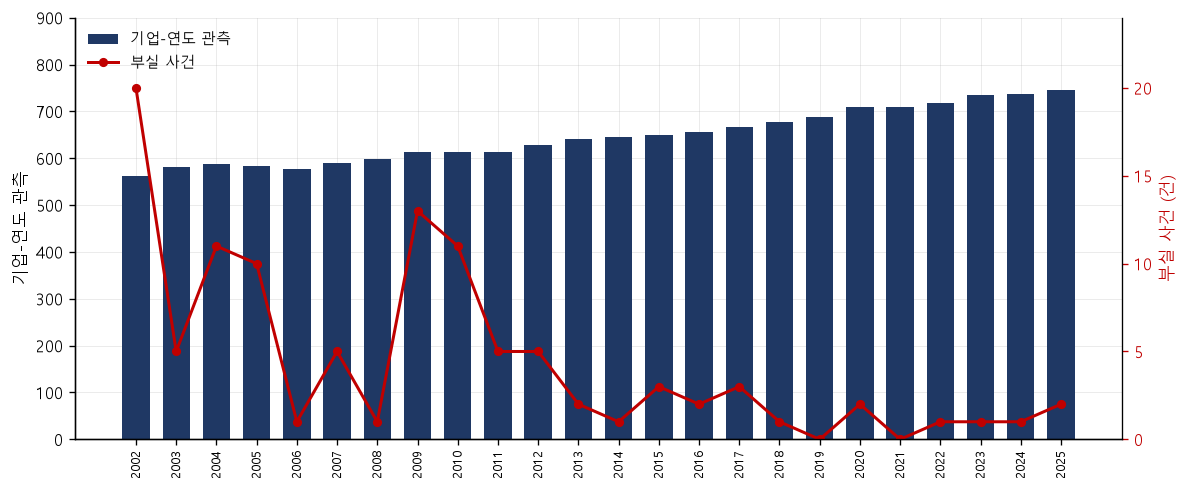

In [3]:
# 그림 1

d = figload('fig_yearly_sample')
yr, n, ev = d['yr'], d['n'], d['ev']

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.bar(yr, n, color=NAVY, width=0.68, label='기업-연도 관측')
ax.set_ylabel('기업-연도 관측')
ax.set_ylim(0, 900)
ax.set_xticks(yr)
ax.set_xticklabels(yr, rotation=90, fontsize=8)
clean(ax)

ax2 = ax.twinx()
ax2.plot(yr, ev, color=RED, marker='o', markersize=4.5, linewidth=1.8, label='부실 사건')
ax2.set_ylabel('부실 사건 (건)', color=RED)
ax2.tick_params(axis='y', colors=RED)
ax2.set_ylim(0, 24)
ax2.grid(False)
for s in ['top']:
    ax2.spines[s].set_visible(False)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper left', frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


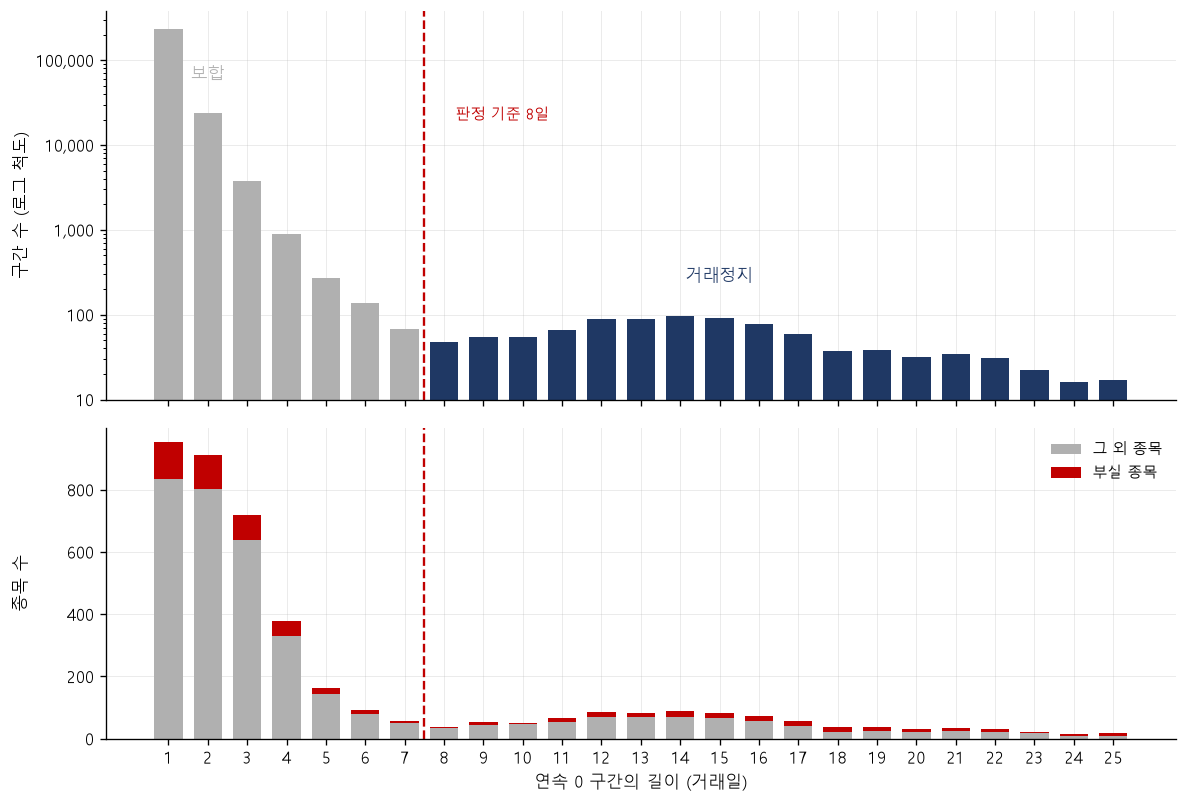

In [4]:
# 그림 2

d = figload('fig_runlen_dist')
L, cnt, codes, bad = d['L'], d['cnt'], d['codes'], d['bad']

fig, axes = plt.subplots(2, 1, figsize=(10, 6.8), sharex=True,
                         gridspec_kw={'height_ratios': [1.25, 1]})

ax = axes[0]
col = [GRAY if x < 8 else NAVY for x in L]
ax.bar(L, cnt, color=col, width=0.72)
ax.set_yscale('log')
ax.set_ylabel('구간 수 (로그 척도)')
ax.axvline(7.5, color=RED, linestyle='--', linewidth=1.4)
ax.text(8.3, 20000, '판정 기준 8일', color=RED, fontsize=9)
ax.annotate('보합', xy=(2, 60000), color=GRAY, fontsize=10, ha='center')
ax.annotate('거래정지', xy=(15, 250), color=NAVY, fontsize=10, ha='center')
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, p: f'{int(v):,}'))
clean(ax)

ax = axes[1]
oth = [c - b for c, b in zip(codes, bad)]
ax.bar(L, oth, color=GRAY, width=0.72, label='그 외 종목')
ax.bar(L, bad, bottom=oth, color=RED, width=0.72, label='부실 종목')
ax.axvline(7.5, color=RED, linestyle='--', linewidth=1.4)
ax.set_xlabel('연속 0 구간의 길이 (거래일)')
ax.set_ylabel('종목 수')
ax.set_xticks(L)
ax.legend(frameon=False, fontsize=9)
clean(ax)

fig.align_ylabels(axes)
plt.tight_layout()
plt.show()


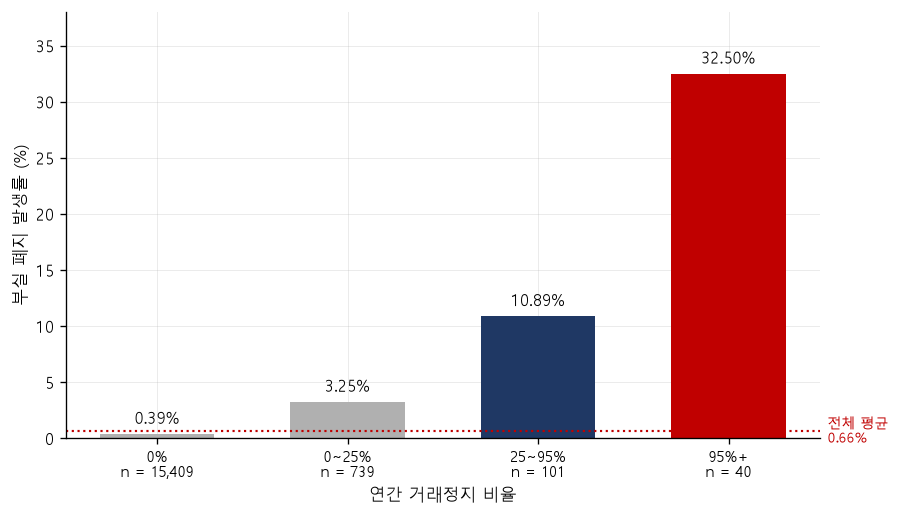

In [5]:
# 그림 3

d = figload('fig_haltrate_event')
lab, rate, obs, mean = d['lab'], d['rate'], d['obs'], d['mean']

fig, ax = plt.subplots(figsize=(7.6, 4.4))
b = ax.bar(lab, rate, color=[GRAY, GRAY, NAVY, RED], width=0.6)
ax.set_xlabel('연간 거래정지 비율')
ax.set_ylabel('부실 폐지 발생률 (%)')
ax.set_ylim(0, 38)
for r, p in zip(rate, b):
    ax.text(p.get_x() + p.get_width() / 2, r + 0.9, f'{r:.2f}%',
            ha='center', fontsize=10, color='black')
ax.set_xticks(range(len(lab)))
ax.set_xticklabels([f'{a}\nn = {o:,}' for a, o in zip(lab, obs)], fontsize=9)
ax.axhline(mean, color=RED, linestyle=':', linewidth=1.3)
ax.text(1.01, mean, f'전체 평균\n{mean:.2f}%', color=RED, fontsize=8.5,
        ha='left', va='center', transform=ax.get_yaxis_transform())
clean(ax)
plt.tight_layout()
plt.show()

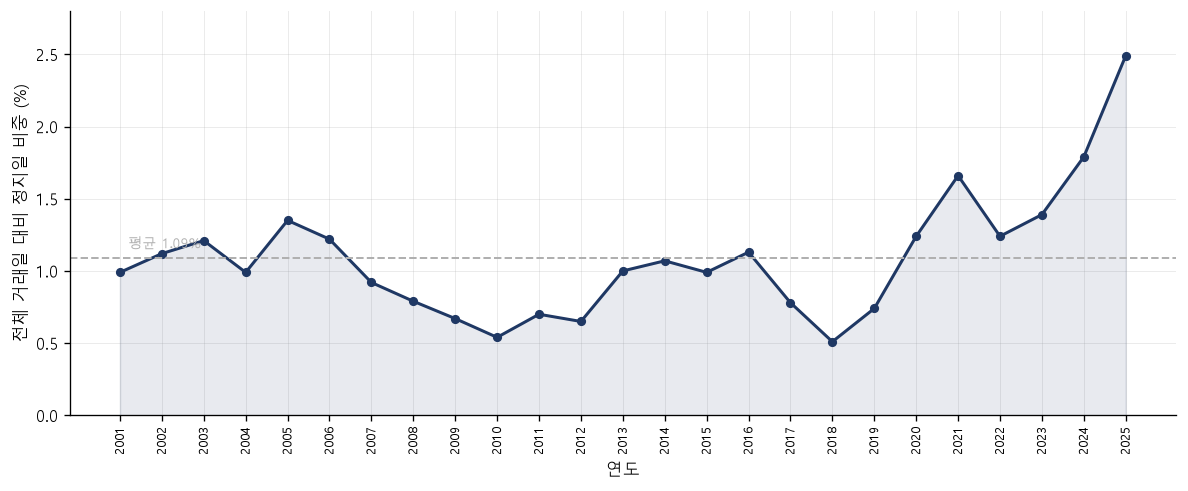

In [6]:
# 그림 4

d = figload('fig_yearly_halt')
yr, pct = d['yr'], d['pct']

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(yr, pct, color=NAVY, marker='o', markersize=4.5, linewidth=1.8)
ax.fill_between(yr, 0, pct, color=NAVY, alpha=0.10)
ax.set_xlabel('연도')
ax.set_ylabel('전체 거래일 대비 정지일 비중 (%)')
ax.set_ylim(0, 2.8)
ax.set_xticks(yr)
ax.set_xticklabels(yr, rotation=90, fontsize=8)
m = float(np.mean(pct))
ax.axhline(m, color=GRAY, linestyle='--', linewidth=1.2)
ax.text(2001.2, m + 0.07, f'평균 {m:.2f}%', color=GRAY, fontsize=8.5)
clean(ax)
plt.tight_layout()
plt.show()

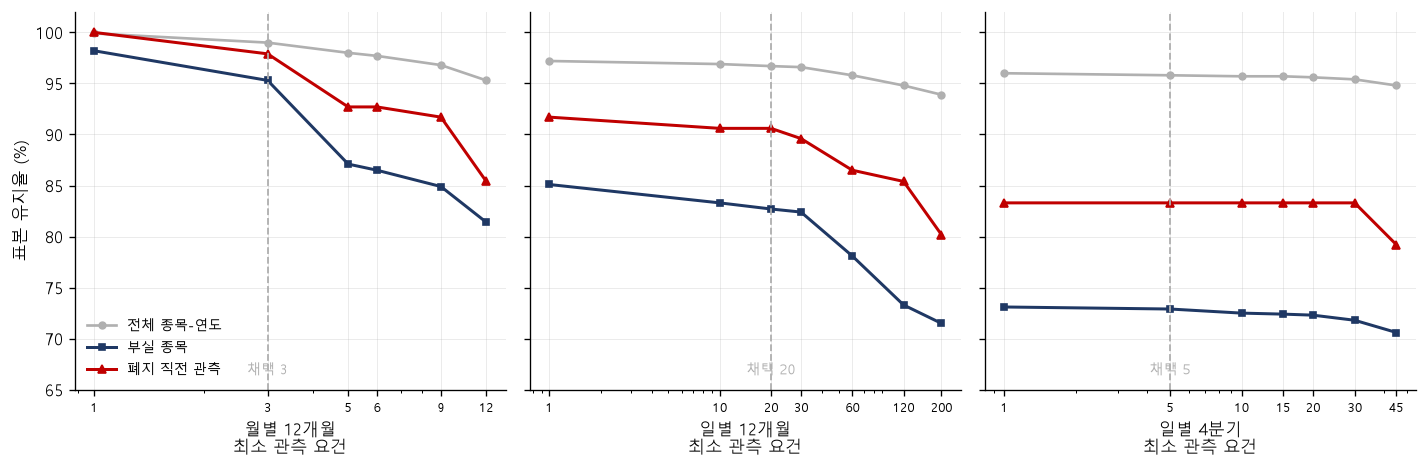

In [7]:
# 그림 5

D = figload('fig_minobs_retention')

fig, axes = plt.subplots(1, 3, figsize=(12, 4.0), sharey=True)
for ax, g in zip(axes, D):
    name, pick = g['name'], g['pick']
    x, a, b, c = g['x'], g['all'], g['bad'], g['pre1']
    ax.plot(x, a, color=GRAY, marker='o', markersize=4, linewidth=1.6, label='전체 종목-연도')
    ax.plot(x, b, color=NAVY, marker='s', markersize=4, linewidth=1.8, label='부실 종목')
    ax.plot(x, c, color=RED, marker='^', markersize=4.5, linewidth=1.8, label='폐지 직전 관측')
    ax.axvline(pick, color=GRAY, linestyle='--', linewidth=1.1)
    ax.text(pick, 66.5, f'채택 {pick}', color=GRAY, fontsize=8.5, ha='center')
    ax.set_xscale('log')
    ax.set_xticks(x)
    ax.set_xticklabels(x, fontsize=8)
    ax.set_xlabel(f'{name}\n최소 관측 요건')
    ax.set_ylim(65, 102)
    clean(ax)
axes[0].set_ylabel('표본 유지율 (%)')
axes[0].legend(loc='lower left', frameon=False, fontsize=8.5)
plt.tight_layout()
plt.show()

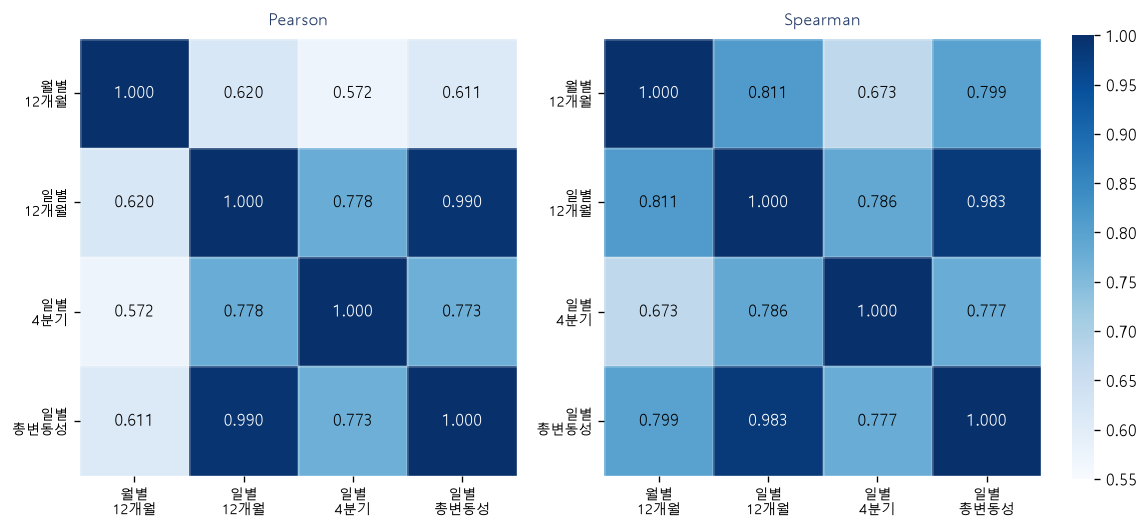

In [8]:
# 그림 6

d = figload('fig_sigma_corr')
names = [n.replace(' ', '\n') for n in d['names']]
P = np.array(d['P'])
S = np.array(d['S'])

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.8))
for ax, M, t in zip(axes, [P, S], ['Pearson', 'Spearman']):
    im = ax.imshow(M, cmap='Blues', vmin=0.55, vmax=1.0)
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(names, fontsize=8.5)
    ax.set_yticklabels(names, fontsize=8.5)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{M[i, j]:.3f}', ha='center', va='center', fontsize=9.5,
                    color='white' if M[i, j] > 0.88 else 'black')
    ax.set_xticks(np.arange(-.5, 4, 1), minor=True)
    ax.set_yticks(np.arange(-.5, 4, 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=1.5)
    ax.grid(which='major', visible=False)
    ax.tick_params(which='minor', length=0)
    ax.set_title(t, fontsize=10, color=NAVY, pad=8)
    for s in ax.spines.values():
        s.set_visible(False)
fig.colorbar(im, ax=axes, fraction=0.030, pad=0.03).outline.set_visible(False)
plt.show()

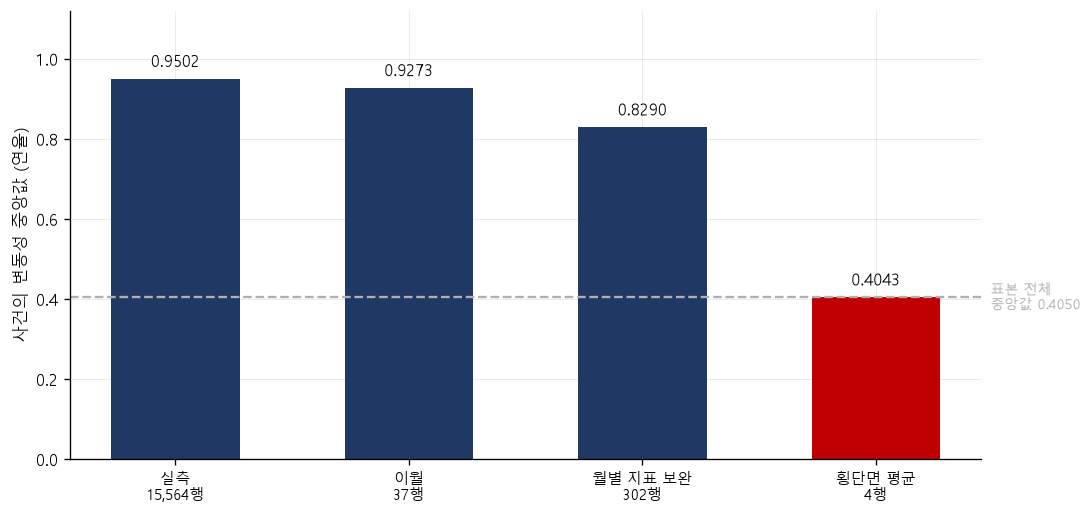

In [9]:
# 그림 7

fig, ax = plt.subplots(figsize=(9.2, 4.4))
d = figload('fig_sigma_fillpath')
paths, sig, rows = d['paths'], d['sig'], d['rows']
median = d['median']
b = ax.bar(paths, sig, color=[NAVY, NAVY, NAVY, RED], width=0.55)
ax.axhline(median, color=GRAY, linestyle='--', linewidth=1.4)
ax.text(1.01, median, f'표본 전체\n중앙값 {median:.4f}', color=GRAY, fontsize=8.5,
        ha='left', va='center', transform=ax.get_yaxis_transform())
ax.set_ylabel('사건의 변동성 중앙값 (연율)')
ax.set_ylim(0, 1.12)
ax.set_xticks(range(len(paths)))
ax.set_xticklabels([f'{p}\n{n:,}행' for p, n in zip(paths, rows)], fontsize=9)
for v, p in zip(sig, b):
    ax.text(p.get_x() + p.get_width() / 2, v + 0.03, f'{v:.4f}', ha='center', fontsize=10)
clean(ax); plt.tight_layout(); plt.show()

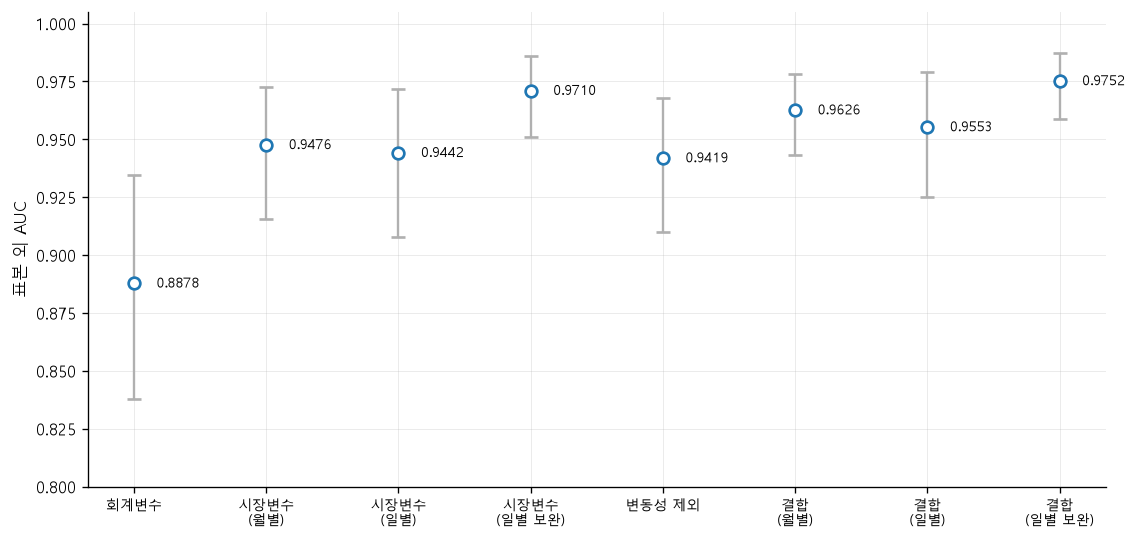

In [10]:
# 그림 8

fig, ax = plt.subplots(figsize=(9.6, 4.6))
d = figload('fig_model_auc')
lab = [l.replace(' (', '\n(') for l in d['lab']]
auc, lo, hi = d['auc'], d['lo'], d['hi']
x = np.arange(len(lab))
col = [GRAY] * 7 + [RED]
ax.errorbar(x, auc, yerr=[np.array(auc) - np.array(lo), np.array(hi) - np.array(auc)],
            fmt='o', markersize=7, capsize=4, elinewidth=1.4,
            ecolor=GRAY, markerfacecolor='white', markeredgewidth=1.6)
for i, c in enumerate(col):
    ax.plot(x[i], auc[i], 'o', markersize=7, color=c)
ax.set_xticks(x); ax.set_xticklabels(lab, fontsize=8.5)
ax.set_ylabel('표본 외 AUC')
ax.set_ylim(0.80, 1.005)
for i, v in enumerate(auc):
    ax.text(x[i] + 0.17, v, f'{v:.4f}', fontsize=8.5, va='center')
clean(ax); plt.tight_layout(); plt.show()

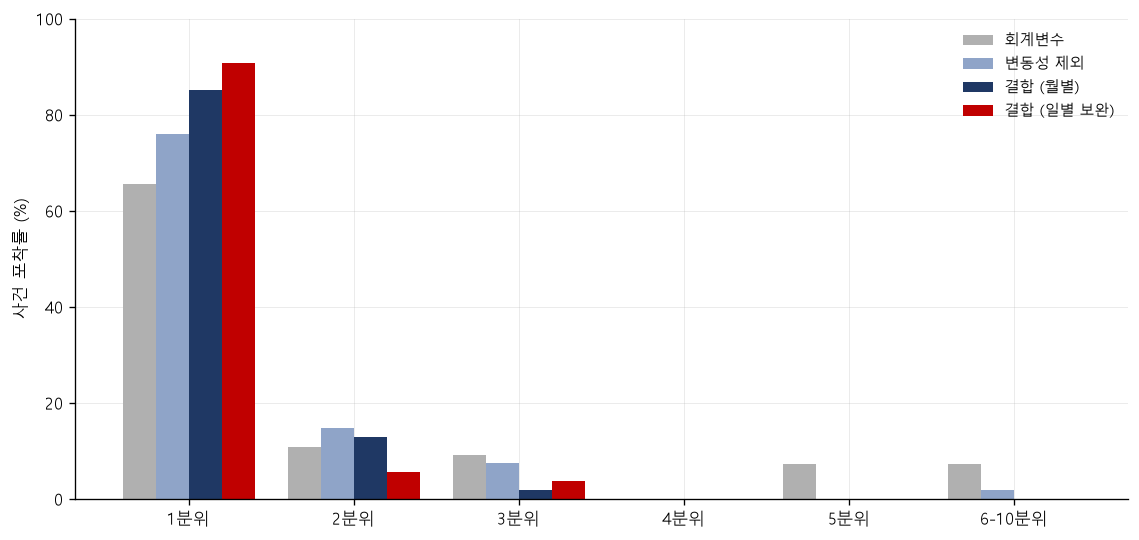

In [11]:
# 그림 9

fig, ax = plt.subplots(figsize=(9.6, 4.6))
d = figload('fig_model_decile')
dec = d['dec']
S = dict(zip(d['lab'], d['val']))
x = np.arange(len(dec)); w = 0.2
cols = [GRAY, '#8FA4C8', NAVY, RED]
for i, ((k, v), c) in enumerate(zip(S.items(), cols)):
    ax.bar(x + (i - 1.5) * w, v, width=w, label=k, color=c)
ax.set_xticks(x); ax.set_xticklabels(dec)
ax.set_ylabel('사건 포착률 (%)')
ax.set_ylim(0, 100)
ax.legend(frameon=False, fontsize=9)
clean(ax); plt.tight_layout(); plt.show()

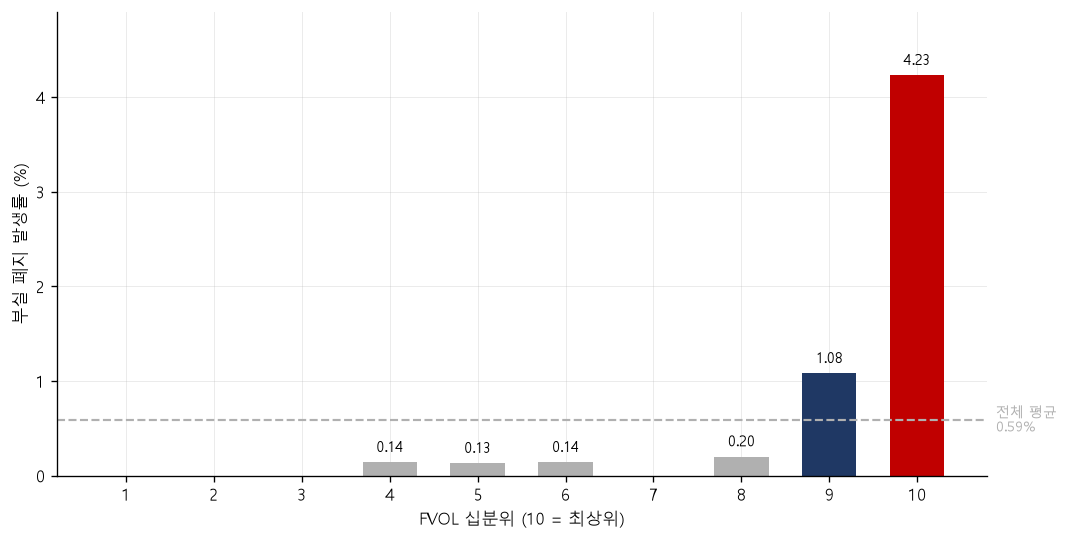

In [12]:
# 그림 10

fig, ax = plt.subplots(figsize=(9.0, 4.6))
d = figload('fig_fvol_decile_rate')
dec, rate, obs, mean = d['dec'], d['rate'], d['obs'], d['mean']
col = [GRAY] * 8 + [NAVY, RED]
b = ax.bar(dec, rate, color=col, width=0.62)
ax.axhline(mean, color=GRAY, linestyle='--', linewidth=1.3)
ax.text(1.01, mean, f'전체 평균\n{mean:.2f}%', color=GRAY, fontsize=8.5,
        ha='left', va='center', transform=ax.get_yaxis_transform())
ax.set_xlabel('FVOL 십분위 (10 = 최상위)')
ax.set_ylabel('부실 폐지 발생률 (%)')
ax.set_xticks(dec)
ax.set_ylim(0, 4.9)
for v, p in zip(rate, b):
    if v > 0:
        ax.text(p.get_x() + p.get_width() / 2, v + 0.11, f'{v:.2f}', ha='center', fontsize=9)

clean(ax); plt.tight_layout(); plt.show()

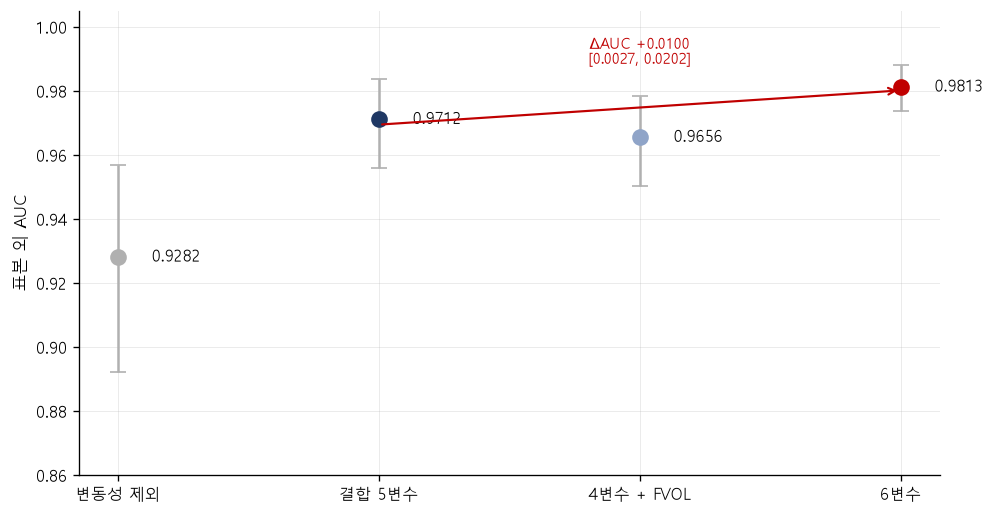

In [13]:
# 그림 11

fig, ax = plt.subplots(figsize=(8.4, 4.4))
d = figload('fig_fvol_auc')
lab, auc, lo, hi = d['lab'], d['auc'], d['lo'], d['hi']
x = np.arange(len(lab))
cols = [GRAY, NAVY, '#8FA4C8', RED]
ax.errorbar(x, auc, yerr=[np.array(auc) - np.array(lo), np.array(hi) - np.array(auc)],
            fmt='none', capsize=5, elinewidth=1.5, ecolor=GRAY)
for i, c in enumerate(cols):
    ax.plot(x[i], auc[i], 'o', markersize=9, color=c)
    ax.text(x[i] + 0.13, auc[i], f'{auc[i]:.4f}', fontsize=9.5, va='center')
ax.set_xticks(x); ax.set_xticklabels(lab, fontsize=9.5)
ax.set_ylabel('표본 외 AUC')
ax.set_ylim(0.86, 1.005)
dd = d['d']
ax.annotate('', xy=(3, auc[3] - 0.0011), xytext=(1, auc[1] - 0.0017),
            arrowprops=dict(arrowstyle='->', color=RED, linewidth=1.3))
ax.text(2.0, auc[3] + 0.0072,
        f"ΔAUC {dd['auc']:+.4f}\n[{dd['lo']:.4f}, {dd['hi']:.4f}]", color=RED,
        fontsize=9, ha='center')
clean(ax); plt.tight_layout(); plt.show()

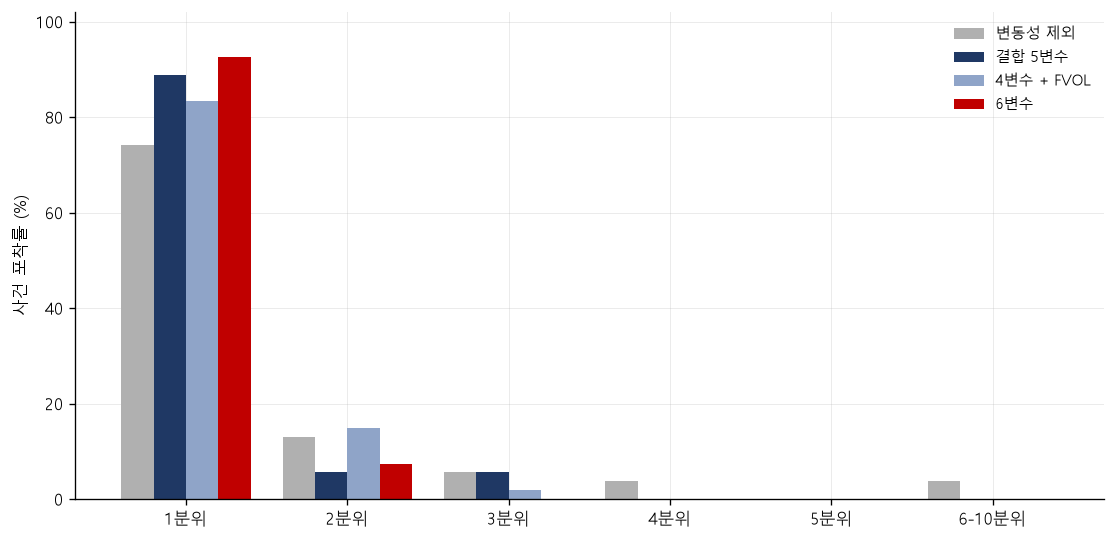

In [14]:
# 그림 12

fig, ax = plt.subplots(figsize=(9.4, 4.6))
d = figload('fig_fvol_decile')
dec = d['dec']
S = dict(zip(d['lab'], d['val']))
x = np.arange(len(dec)); w = 0.2
cols = [GRAY, NAVY, '#8FA4C8', RED]
for i, ((k, v), c) in enumerate(zip(S.items(), cols)):
    ax.bar(x + (i - 1.5) * w, v, width=w, label=k, color=c)
ax.set_xticks(x); ax.set_xticklabels(dec)
ax.set_ylabel('사건 포착률 (%)')
ax.set_ylim(0, 102)
ax.legend(frameon=False, fontsize=9)
clean(ax); plt.tight_layout(); plt.show()

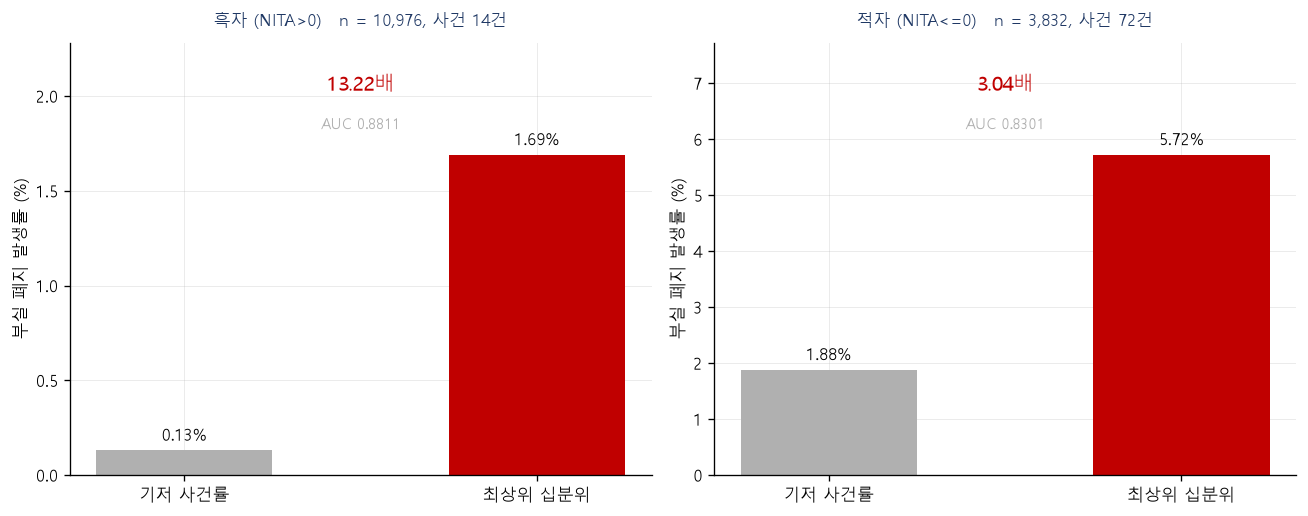

In [15]:
# 그림 13

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.4))
for ax, g in zip(axes, figload('fig_fvol_profit_split')):
    name, base, top = g['name'], g['base'], g['top']
    mult, auc, n, ev = g['mult'], g['auc'], g['n'], g['ev']
    b = ax.bar(['기저 사건률', '최상위 십분위'], [base, top],
               color=[GRAY, RED], width=0.5)
    for v, p in zip([base, top], b):
        ax.text(p.get_x() + p.get_width() / 2, v + top * 0.03, f'{v:.2f}%',
                ha='center', fontsize=10)
    ax.set_ylim(0, top * 1.35)
    ax.set_ylabel('부실 폐지 발생률 (%)')
    ax.set_title(f'{name}   n = {n:,}, 사건 {ev}건', fontsize=10, color=NAVY, pad=10)
    ax.text(0.5, top * 1.20, f'{mult:.2f}배', ha='center', color=RED, fontsize=12)
    ax.text(0.5, top * 1.08, f'AUC {auc:.4f}', ha='center', color=GRAY, fontsize=9)
    clean(ax)
plt.tight_layout(); plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_22908\1208469592.py:20: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  clean(ax); plt.tight_layout(); plt.show()
c:\Users\user\Desktop\vs\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


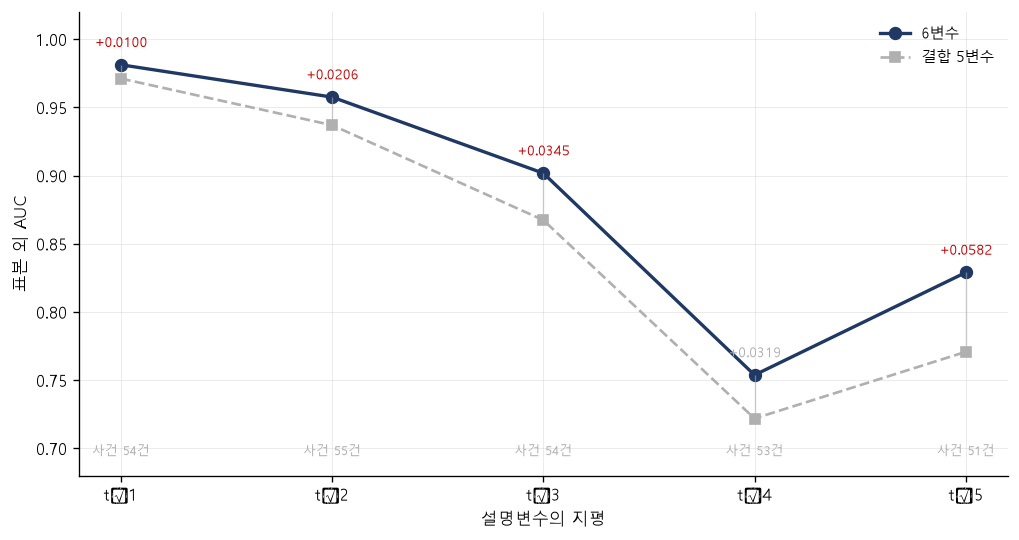

In [16]:
# 그림 14

fig, ax = plt.subplots(figsize=(8.6, 4.6))
d = figload('fig_horizon_auc')
hor, a5, a6 = d['hor'], d['auc5'], d['auc6']
hor = [h.replace('\u2212', '-') for h in hor]
x = np.arange(len(hor))
ax.plot(x, a6, 'o-', color=NAVY, markersize=7, linewidth=2.0, label='6변수')
ax.plot(x, a5, 's--', color=GRAY, markersize=6, linewidth=1.6, label='결합 5변수')
for i in range(len(x)):
    ax.vlines(x[i], a5[i], a6[i], color=GRAY, linewidth=0.8, alpha=0.6)
    ax.text(x[i], a6[i] + 0.013, f"{d['d'][i]:+.4f}", ha='center', fontsize=8.5,
            color=RED if d['lo'][i] > 0 else GRAY)
ax.set_xticks(x); ax.set_xticklabels(hor, fontsize=10)
ax.set_xlabel('설명변수의 지평')
ax.set_ylabel('표본 외 AUC')
ax.set_ylim(0.68, 1.02)
for i, e in enumerate(d['ev']):
    ax.text(x[i], 0.695, f'사건 {e}건', ha='center', fontsize=8, color=GRAY)
ax.legend(frameon=False, fontsize=9, loc='upper right')
clean(ax); plt.tight_layout(); plt.show()

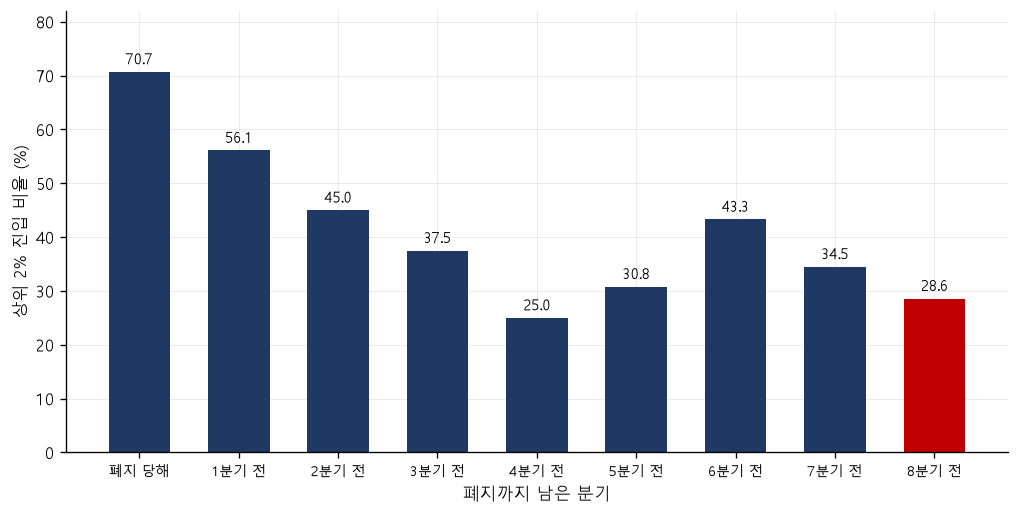

In [17]:
# 그림 15

fig, ax = plt.subplots(figsize=(8.6, 4.4))
d = figload('fig_quarter_lead')
lag, pct = d['lag'], d['pct']
col = [NAVY] * (len(lag) - 1) + [RED]
b = ax.bar(lag, pct, color=col, width=0.62)
for v, p in zip(pct, b):
    ax.text(p.get_x() + p.get_width() / 2, v + 1.4, f'{v:.1f}', ha='center', fontsize=9)
ax.set_xlabel('폐지까지 남은 분기')
ax.set_ylabel('상위 2% 진입 비율 (%)')
ax.set_xticks(lag)
ax.set_xticklabels(['폐지 당해'] + [f'{k}분기 전' for k in lag[1:]], fontsize=8.5)
ax.set_ylim(0, 82)
clean(ax); plt.tight_layout(); plt.show()

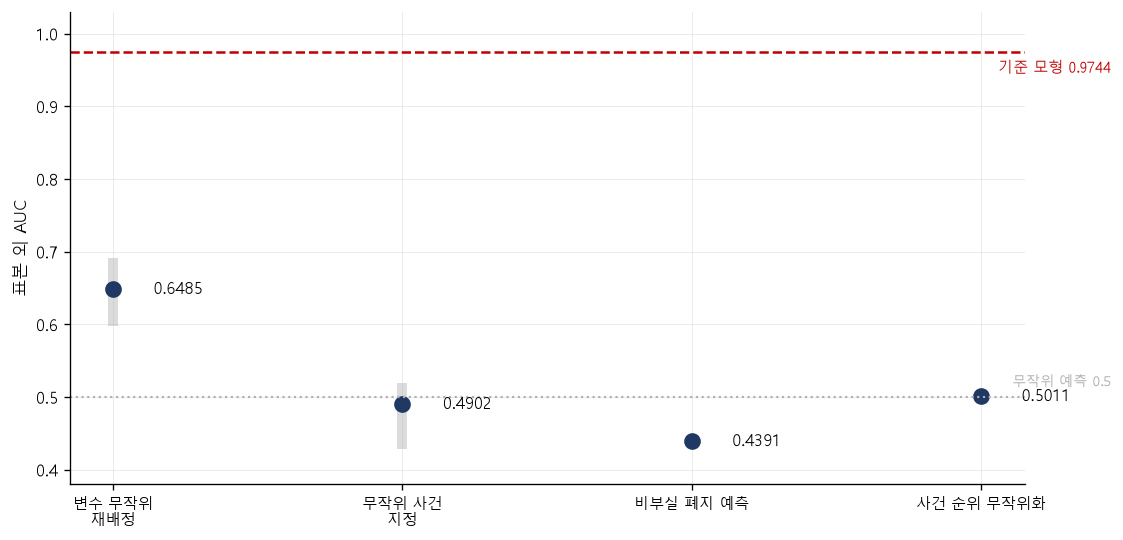

In [18]:
# 그림 16

fig, ax = plt.subplots(figsize=(9.4, 4.6))
P14 = [figload('fig_negctrl_var'), figload('fig_negctrl_event'),
       figload('fig_negctrl_nonbad'), figload('fig_negctrl_rank')]
lab = [g['name'] for g in P14]
val = [g['val'] for g in P14]
rng = [(g['lo'], g['hi']) if 'lo' in g else None for g in P14]
_base = P14[0]['base']
x = np.arange(len(lab))
for i, (v, r) in enumerate(zip(val, rng)):
    if r:
        ax.vlines(x[i], r[0], r[1], color=GRAY, linewidth=6, alpha=0.45)
    ax.plot(x[i], v, 'o', markersize=9, color=NAVY)
    ax.text(x[i] + 0.14, v, f'{v:.4f}', fontsize=9.5, va='center')
ax.axhline(0.5, color=GRAY, linestyle=':', linewidth=1.3)
ax.text(3.45, 0.515, '무작위 예측 0.5', color=GRAY, fontsize=8.5, ha='right')
ax.axhline(_base, color=RED, linestyle='--', linewidth=1.5)
ax.text(3.45, _base - 0.028, f'기준 모형 {_base:.4f}', color=RED, fontsize=9,
        ha='right')
ax.set_xticks(x); ax.set_xticklabels(lab, fontsize=9)
ax.set_ylabel('표본 외 AUC')
ax.set_ylim(0.38, 1.03)
clean(ax); plt.tight_layout(); plt.show()

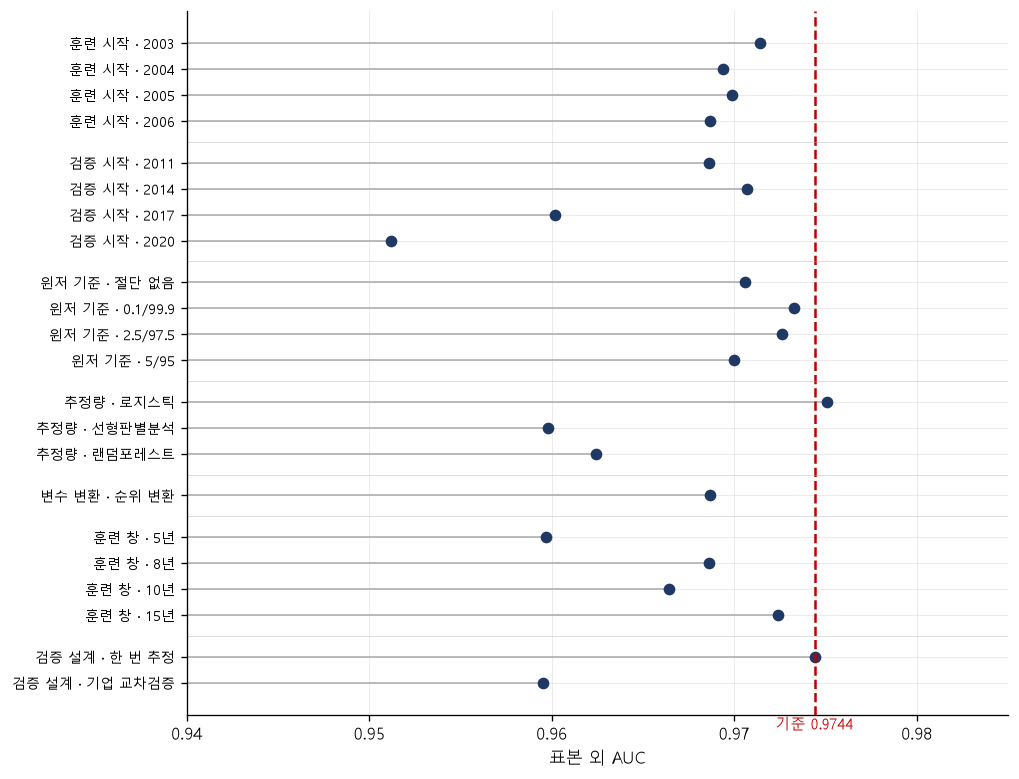

In [19]:
# 그림 17

fig, ax = plt.subplots(figsize=(8.6, 6.6))
_rows = figload('fig_specsens_a') + figload('fig_specsens_b')
G = []
for _g, _l, _v in _rows:
    if G and G[-1][0] == _g:
        G[-1][1].append(_l); G[-1][2].append(_v)
    else:
        G.append([_g, [_l], [_v]])
ypos, ylab, yval, sep = [], [], [], []
k = 0
for g, ls, vs in G:
    for l, v in zip(ls, vs):
        ypos.append(k); ylab.append(f'{g} · {l}'); yval.append(v); k += 1
    sep.append(k - 0.5); k += 0.6
ax.hlines(ypos, 0.94, yval, color=GRAY, linewidth=1.0)
ax.plot(yval, ypos, 'o', markersize=6, color=NAVY)
_b15 = figload('fig_negctrl_var')['base']
ax.axvline(_b15, color=RED, linestyle='--', linewidth=1.5)
ax.text(_b15, k + 0.2, f'기준 {_b15:.4f}', color=RED, fontsize=9, ha='center')
for s in sep[:-1]:
    ax.axhline(s + 0.3, color=GRAY, linewidth=0.5, alpha=0.5)
ax.set_yticks(ypos); ax.set_yticklabels(ylab, fontsize=8.5)
ax.invert_yaxis()
ax.set_xlabel('표본 외 AUC')
ax.set_xlim(0.94, 0.985)
clean(ax); plt.tight_layout(); plt.show()

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


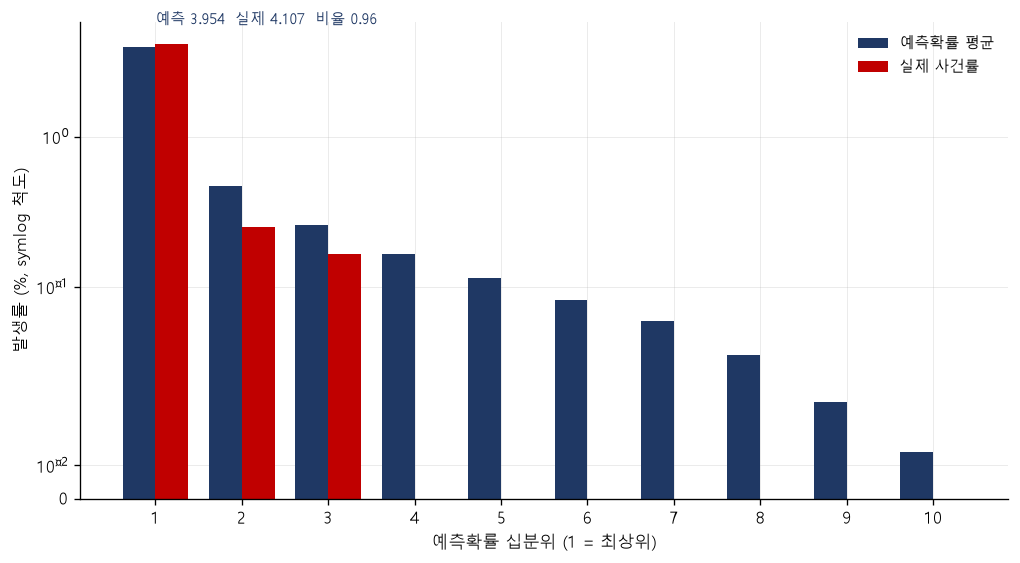

In [20]:
# 그림 18

fig, ax = plt.subplots(figsize=(8.6, 4.8))
d = figload('fig_calibration')
dec, pred, actu = d['dec'], d['pred'], d['actu']
w = 0.38
x = np.arange(len(dec))
ax.bar(x - w / 2, pred, width=w, color=NAVY, label='예측확률 평균')
ax.bar(x + w / 2, actu, width=w, color=RED, label='실제 사건률')
ax.set_yscale('symlog', linthresh=0.05)
ax.set_xticks(x); ax.set_xticklabels(dec)
ax.set_xlabel('예측확률 십분위 (1 = 최상위)')
ax.set_ylabel('발생률 (%, symlog 척도)')
ax.legend(frameon=False, fontsize=9)
_r = f'  비율 {pred[0] / actu[0]:.2f}' if actu[0] else ''
ax.text(0, 5.6, f'예측 {pred[0]:.3f}  실제 {actu[0]:.3f}{_r}',
        color=NAVY, fontsize=9, ha='left')
clean(ax); plt.tight_layout(); plt.show()

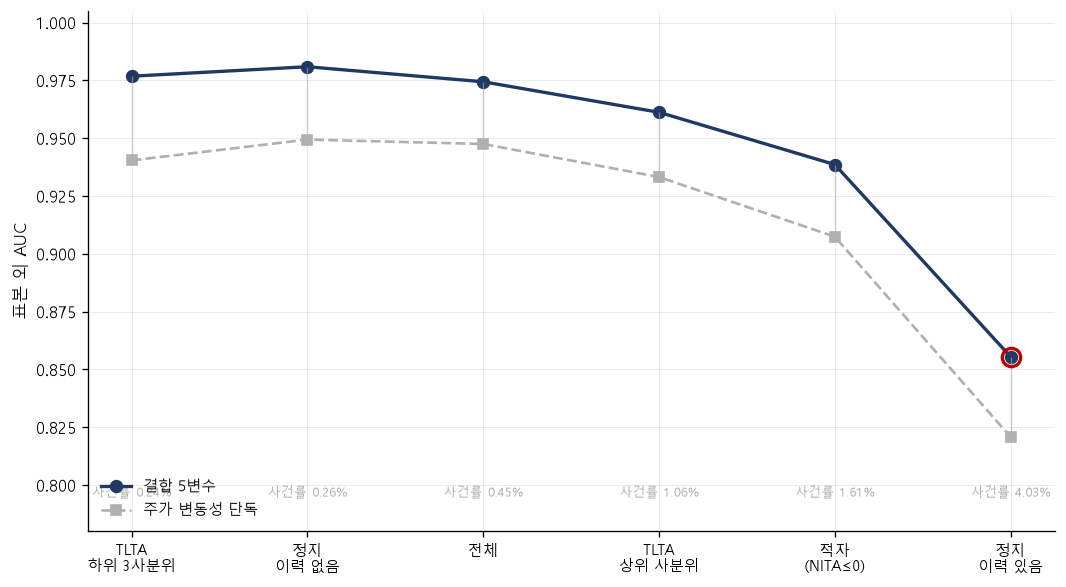

In [21]:
# 그림 19

fig, ax = plt.subplots(figsize=(9.0, 5.0))
d = figload('fig_subsample_auc')
sub = [s.replace(' ', '\n', 1) for s in d['sub']]
rate, m5, m1 = d['rate'], d['m5'], d['m1']
x = np.arange(len(sub))
ax.plot(x, m5, 'o-', color=NAVY, markersize=7, linewidth=2.0, label='결합 5변수')
ax.plot(x, m1, 's--', color=GRAY, markersize=6, linewidth=1.6, label='주가 변동성 단독')
for i, (a, b) in enumerate(zip(m5, m1)):
    ax.vlines(x[i], b, a, color=GRAY, linewidth=0.8, alpha=0.6)
ax.plot(x[-1], m5[-1], 'o', markersize=11, markerfacecolor='none',
        markeredgecolor=RED, markeredgewidth=2.0)
ax.set_xticks(x); ax.set_xticklabels(sub, fontsize=9)
ax.set_ylabel('표본 외 AUC')
ax.set_ylim(0.78, 1.005)
for i, r in enumerate(rate):
    ax.text(x[i], 0.795, f'사건률 {r:.2f}%', ha='center', fontsize=8, color=GRAY)
ax.legend(frameon=False, fontsize=9, loc='lower left')
clean(ax); plt.tight_layout(); plt.show()

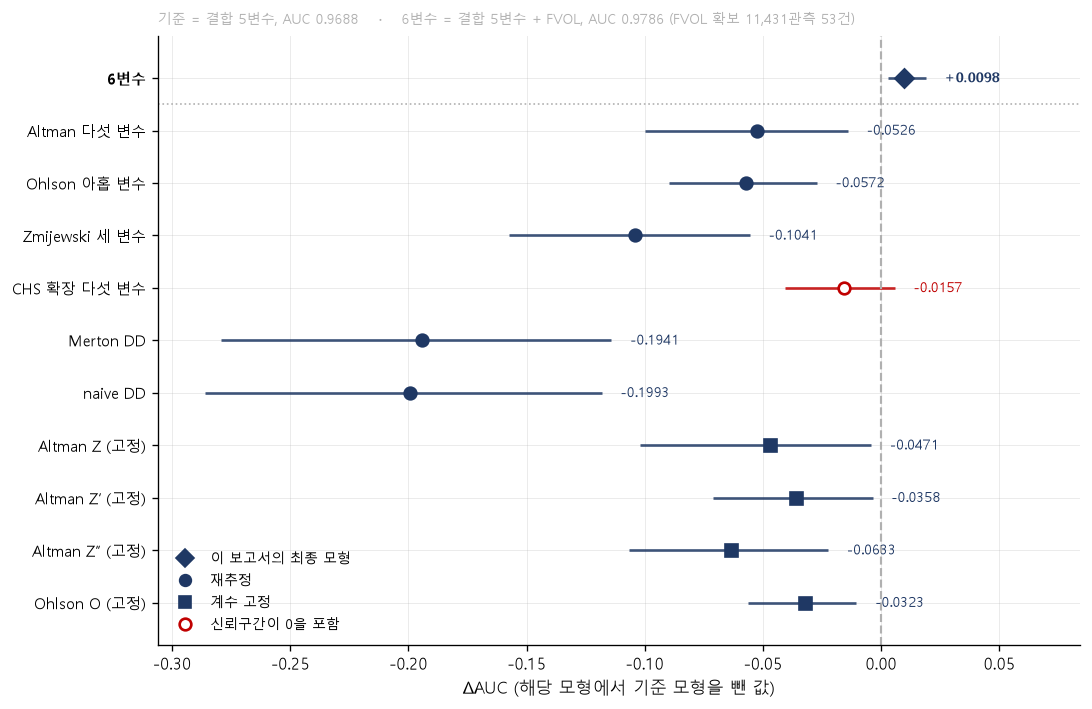

In [10]:
# 그림 20

fig, ax = plt.subplots(figsize=(9.2, 6.0))
d = figload('fig_altcmp_forest')
ref_auc = d['ref_auc']
six = 'six_d' in d

rows = []
if six:
    rows.append(('6변수', d['six_d'], d['six_lo'], d['six_hi'], 'six'))
rows += list(zip(d['lab'], d['d'], d['lo'], d['hi'], d['kind']))

y = np.arange(len(rows))[::-1]
for i, (nm, v, l, h, k) in enumerate(rows):
    zero_in = l <= 0 <= h
    c = RED if zero_in else NAVY
    mk = {'six': 'D', '재추정': 'o'}.get(k, 's')
    ax.hlines(y[i], l, h, color=c, linewidth=1.6, alpha=0.85)
    ax.plot(v, y[i], mk, markersize=8 if k == 'six' else 7, color=c,
            markerfacecolor='white' if zero_in else c, markeredgewidth=1.6)
    ax.text(h + 0.008, y[i], f'{v:+.4f}', fontsize=8.5, va='center', color=c,
            fontweight='bold' if k == 'six' else 'normal')

los = [r[2] for r in rows]
his = [r[3] for r in rows]
ax.axvline(0, color=GRAY, linestyle='--', linewidth=1.3)
if six:
    ax.axhline(y[0] - 0.5, color=GRAY, linestyle=':', linewidth=1.0)
ax.set_yticks(y)
ax.set_yticklabels([r[0] for r in rows], fontsize=9)
if six:
    ax.get_yticklabels()[0].set_fontweight('bold')
ax.set_ylim(-0.8, len(rows) - 0.2)
ax.set_xlabel('ΔAUC (해당 모형에서 기준 모형을 뺀 값)')
ax.set_xlim(min(los) - 0.02, max(his) + 0.065)
if six:
    ax.plot([], [], 'D', color=NAVY, markersize=8, label='이 보고서의 최종 모형')
ax.plot([], [], 'o', color=NAVY, markersize=7, label='재추정')
ax.plot([], [], 's', color=NAVY, markersize=7, label='계수 고정')
ax.plot([], [], 'o', color=RED, markersize=7, markerfacecolor='white',
        markeredgewidth=1.6, label='신뢰구간이 0을 포함')
ax.legend(frameon=False, fontsize=8.5, loc='lower left')
cap = f'기준 = 결합 5변수, AUC {ref_auc:.4f}'
if six:
    cap += (f'    ·    6변수 = 결합 5변수 + FVOL, AUC {d["six_auc"]:.4f}'
            f' (FVOL 확보 {d["six_n"]:,}관측 {d["six_ev"]}건)')
ax.text(0.0, 1.02, cap, color=GRAY, fontsize=8.5, transform=ax.transAxes)
clean(ax); plt.tight_layout(); plt.show()

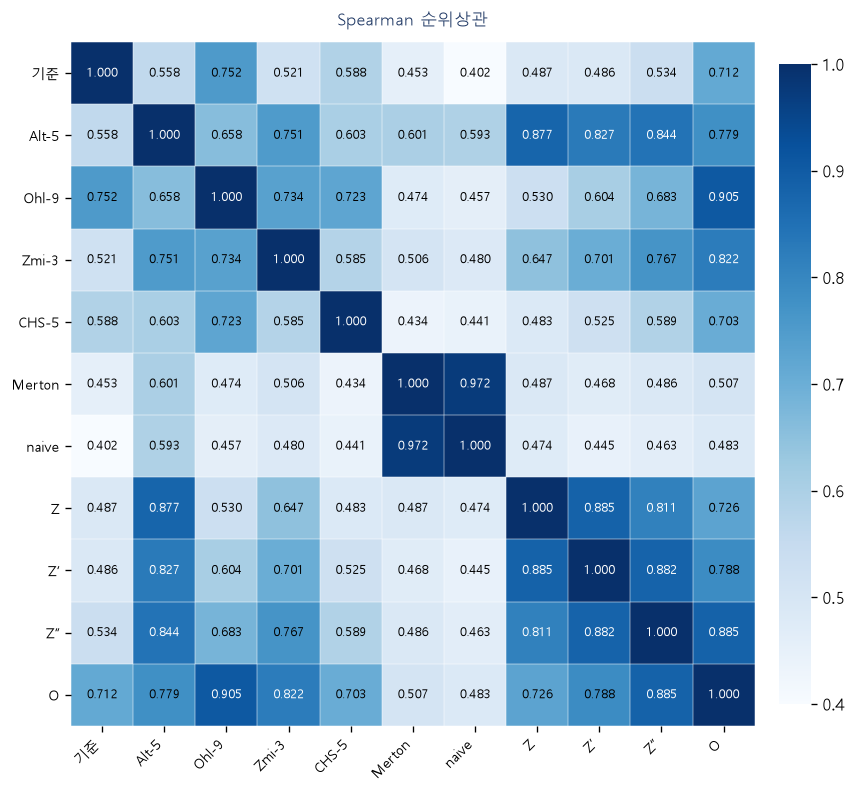

In [23]:
# 그림 21

ABBR = {'우리 5변수': '5변수', '우리 6변수': '6변수',
        'Altman 다섯 변수': 'Alt-5', 'Ohlson 아홉 변수': 'Ohl-9',
        'Zmijewski 세 변수': 'Zmi-3', 'CHS 확장 다섯 변수': 'CHS-5',
        'Merton DD': 'Merton', 'naive DD': 'naive', 'Altman Z (고정)': 'Z',
        'Altman Z′ (고정)': 'Z′', 'Altman Z″ (고정)': 'Z″', 'Ohlson O (고정)': 'O'}
OURS = {'5변수', '6변수'}

d = figload('fig_altcmp_corr')
names = [ABBR.get(n, n) for n in d['names']]
S = np.array(d['S'])
k = len(names)

fig, ax = plt.subplots(figsize=(9.2, 7.9))
im = ax.imshow(S, cmap='Blues', vmin=0.40, vmax=1.0)
ax.set_xticks(range(k)); ax.set_yticks(range(k))
ax.set_xticklabels(names, fontsize=8.5, rotation=45, ha='right')
ax.set_yticklabels(names, fontsize=8.5)
for t in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
    if t.get_text() in OURS:
        t.set_fontweight('bold'); t.set_color(NAVY)
for i in range(k):
    for j in range(k):
        ax.text(j, i, f'{S[i, j]:.3f}', ha='center', va='center', fontsize=6.6,
                color='white' if S[i, j] > 0.80 else 'black')
ax.set_xticks(np.arange(-.5, k, 1), minor=True)
ax.set_yticks(np.arange(-.5, k, 1), minor=True)
ax.grid(which='minor', color='white', linewidth=1.2)
ax.grid(which='major', visible=False)
ax.tick_params(which='minor', length=0)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title('Spearman 순위상관', fontsize=10, color=NAVY, pad=10)
fig.colorbar(im, ax=ax, fraction=0.040, pad=0.03).outline.set_visible(False)
plt.show()